# Production worker memory analysis

This notebook analyzes the production worker's durable diagnostics across all selected JSONL segments. GCS is the default source because it retains closed segments after VM restarts; VM and local sources remain available for an active segment or offline artifacts. It writes a combined `memory.csv`, `summary.json`, and `source-manifest.json`, then plots the full selected timeline.

The JSONL records are the source of truth. Selection is controlled in the first code cell: by default all retained worker segments are included. Set `LOOKBACK_HOURS`, `MAX_FILES`, or `MAX_TOTAL_BYTES` to bound a run; limits never silently discard data. The download is read-only and never exports credentials, command lines, environments, prompts, broker payloads, or raw market data.

In [15]:
from pathlib import Path
from datetime import datetime, timezone
import json
import subprocess
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

PROJECT = 'ai-trader-prod-501108'
ZONE = 'us-central1-b'
INSTANCE = 'ai-trader-worker'
REMOTE_DIAGNOSTICS = '/var/lib/ai-trader/diagnostics'
GCS_DIAGNOSTICS_URI = 'gs://backup-bucket-e17fa12/market-data/diagnostics/ai-trader-worker'
DATA_SOURCE = 'gcs'  # 'gcs' (durable history), 'vm' (active files), or 'local' (offline artifacts).
LOOKBACK_HOURS = None  # None = all retained history; e.g. 48 for the latest two days.
MAX_FILES = None  # None = all matching segments.
MAX_TOTAL_BYTES = None  # None = no artificial cap; a cap fails clearly rather than truncating.
INCLUDE_ACTIVE_VM = True  # Include the current VM segment when it is not already in GCS.
LOCAL_INPUT_PATHS = []  # Optional files/directories when DATA_SOURCE='local'.
RUN_DIRECTORY_OVERRIDE = None  # Backward-compatible alias for one local artifact directory.
GCLOUD = shutil.which('gcloud.cmd') or shutil.which('gcloud')
if GCLOUD is None:
    standard_windows_path = Path('C:/Program Files (x86)/Google/Cloud SDK/google-cloud-sdk/bin/gcloud.cmd')
    if standard_windows_path.exists():
        GCLOUD = str(standard_windows_path)
if GCLOUD is None:
    raise FileNotFoundError('gcloud.cmd was not found. Install the Google Cloud SDK or set GCLOUD to its executable path.')

def find_repo_root():
    for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
        if (candidate / 'artifacts').exists() and (candidate / 'src').exists():
            return candidate.resolve()
    return Path.cwd().resolve()

REPO_ROOT = find_repo_root()
ARTIFACT_ROOT = REPO_ROOT / 'artifacts'
print(f'Repository root: {REPO_ROOT}')
print(f'VM: {INSTANCE} ({PROJECT}, {ZONE})')

Repository root: C:\OpenSource\Sam\ai-trader-ig
VM: ai-trader-worker (ai-trader-prod-501108, us-central1-b)


In [16]:
def run_command(args, binary=False):
    result = subprocess.run(args, capture_output=True, text=not binary)
    if result.returncode != 0:
        detail = result.stderr.decode(errors='replace') if binary else result.stderr
        raise RuntimeError(f'Command failed ({result.returncode}): {detail}')
    return result.stdout

def run_gcloud_ssh(command, binary=False):
    return run_command([GCLOUD, 'compute', 'ssh', INSTANCE, '--zone', ZONE, '--project', PROJECT, '--command', command], binary=binary)

def gcs_objects():
    entries = json.loads(run_command([GCLOUD, 'storage', 'ls', '--recursive', '--json', GCS_DIAGNOSTICS_URI + '/']))
    objects = []
    for entry in entries:
        metadata = entry.get('metadata') or {}
        name = metadata.get('name')
        if not name or not Path(name).name.startswith('worker-') or not Path(name).name.endswith('.jsonl'):
            continue
        objects.append({
            'source': 'gcs',
            'uri': entry.get('url', '').split('#', 1)[0],
            'name': Path(name).name,
            'sizeBytes': int(metadata.get('size', 0)),
            'updated': metadata.get('updated'),
        })
    return objects

def vm_objects():
    listing = run_gcloud_ssh(f"sudo find {REMOTE_DIAGNOSTICS} -maxdepth 1 -type f -name 'worker-*.jsonl*' -printf '%s %p\\n' | sort -k2").strip()
    objects = []
    for line in listing.splitlines():
        parts = line.split(maxsplit=1)
        if len(parts) != 2:
            continue
        remote_path = parts[1].strip()
        objects.append({'source': 'vm', 'remotePath': remote_path, 'name': Path(remote_path).name.replace('.active', ''), 'sizeBytes': int(parts[0])})
    return objects

def local_objects(paths):
    candidates = []
    for configured in paths:
        path = Path(configured).expanduser().resolve()
        if path.is_file():
            candidates.append(path)
        elif path.is_dir():
            candidates.extend(sorted(path.rglob('*.jsonl*')))
        else:
            raise FileNotFoundError(f'Local diagnostics path does not exist: {path}')
    return [{'source': 'local', 'path': path, 'name': path.name.replace('.active', ''), 'sizeBytes': path.stat().st_size} for path in candidates]

if RUN_DIRECTORY_OVERRIDE:
    DATA_SOURCE = 'local'
    LOCAL_INPUT_PATHS = [RUN_DIRECTORY_OVERRIDE]

if DATA_SOURCE not in {'gcs', 'vm', 'local'}:
    raise ValueError("DATA_SOURCE must be 'gcs', 'vm', or 'local'.")
if DATA_SOURCE == 'gcs':
    candidates = gcs_objects()
    if INCLUDE_ACTIVE_VM:
        known_names = {item['name'] for item in candidates}
        candidates.extend(item for item in vm_objects() if item['name'] not in known_names)
elif DATA_SOURCE == 'vm':
    candidates = vm_objects()
else:
    candidates = local_objects(LOCAL_INPUT_PATHS)

if not candidates:
    raise FileNotFoundError('No worker JSONL diagnostics segments were found.')
if MAX_FILES is not None:
    candidates = sorted(candidates, key=lambda item: item.get('updated') or '', reverse=True)[:int(MAX_FILES)]
total_bytes = sum(item['sizeBytes'] for item in candidates)
if MAX_TOTAL_BYTES is not None and total_bytes > int(MAX_TOTAL_BYTES):
    raise ValueError(f'Selected diagnostics total {total_bytes:,} bytes exceeds MAX_TOTAL_BYTES={int(MAX_TOTAL_BYTES):,}; increase the limit or set it to None.')

stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
RUN_DIRECTORY = Path(RUN_DIRECTORY_OVERRIDE).expanduser().resolve() if RUN_DIRECTORY_OVERRIDE else ARTIFACT_ROOT / f'production-diagnostics-{stamp}'
RUN_DIRECTORY.mkdir(parents=True, exist_ok=True)
JSONL_PATHS = []
for index, item in enumerate(candidates):
    if item['source'] == 'local':
        local_path = item['path']
    else:
        target = RUN_DIRECTORY / f"{index:04d}-{item['name']}"
        if item['source'] == 'gcs':
            target.write_bytes(run_command([GCLOUD, 'storage', 'cat', item['uri']], binary=True))
        else:
            target.write_bytes(run_gcloud_ssh(f"sudo cat {item['remotePath']}", binary=True))
        local_path = target
    item['localPath'] = str(local_path)
    JSONL_PATHS.append(local_path)

manifest = {
    'source': DATA_SOURCE,
    'gcsDiagnosticsUri': GCS_DIAGNOSTICS_URI,
    'lookbackHours': LOOKBACK_HOURS,
    'maxFiles': MAX_FILES,
    'maxTotalBytes': MAX_TOTAL_BYTES,
    'selectedFileCount': len(candidates),
    'selectedBytes': total_bytes,
    'files': [{key: value for key, value in item.items() if key != 'path'} for item in candidates],
}
(RUN_DIRECTORY / 'source-manifest.json').write_text(json.dumps(manifest, indent=2, default=str), encoding='utf-8')
(RUN_DIRECTORY / 'source.txt').write_text(f'source={DATA_SOURCE}\nfiles={len(candidates)}\nbytes={total_bytes}\ndownloaded-at-utc={datetime.now(timezone.utc).isoformat()}\n', encoding='utf-8')
print(f'Run directory: {RUN_DIRECTORY}')
print(f'Selected {len(JSONL_PATHS)} JSONL segments ({total_bytes:,} bytes) from {DATA_SOURCE}.')
for path in JSONL_PATHS:
    print(f'  {path.name} ({path.stat().st_size:,} bytes)')

Run directory: C:\OpenSource\Sam\ai-trader-ig\artifacts\production-diagnostics-20260717T114755Z
Raw JSONL: C:\OpenSource\Sam\ai-trader-ig\artifacts\production-diagnostics-20260717T114755Z\worker-22635-c20952cb7456413eb56818912193b8f0-0004.jsonl (2,209,159 bytes)


In [17]:
def value(obj, *keys):
    for key in keys:
        if obj is None:
            return None
        obj = obj.get(key) if isinstance(obj, dict) else None
    return obj

records = []
malformed_lines = []
duplicate_records = 0
seen_records = set()
for candidate, jsonl_path in zip(candidates, JSONL_PATHS):
    segment_key = candidate['name']
    with jsonl_path.open(encoding='utf-8-sig') as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                event = json.loads(line)
            except json.JSONDecodeError:
                malformed_lines.append({'file': segment_key, 'line': line_number})
                continue
            sequence = event.get('sequence')
            dedupe_key = (segment_key, sequence) if sequence is not None else (segment_key, event.get('observedAtUtc'), line_number)
            if dedupe_key in seen_records:
                duplicate_records += 1
                continue
            seen_records.add(dedupe_key)
            process = event.get('process') or {}
            linux = process.get('linux') or {}
            runtime = process.get('managedRuntime') or {}
            cgroup = event.get('cgroup') or {}
            operations = event.get('operations') or {}
            stream = event.get('stream') or {}
            records.append({
                'timestampUtc': event.get('observedAtUtc'),
                'sequence': sequence,
                'segment': segment_key,
                'source': candidate['source'],
                'pid': process.get('processId'),
                'uptime': process.get('uptime'),
                'workingSetBytes': process.get('workingSetBytes'),
                'privateMemoryBytes': process.get('privateMemoryBytes'),
                'rssBytes': linux.get('residentSetBytes'),
                'pssBytes': linux.get('pssBytes'),
                'anonymousBytes': linux.get('anonymousBytes'),
                'fileBytes': linux.get('fileBytes'),
                'sharedMemoryBytes': linux.get('sharedMemoryBytes'),
                'privateDirtyBytes': linux.get('privateDirtyBytes'),
                'stackBytes': linux.get('stackBytes'),
                'threadCount': process.get('threadCount'),
                'cgroupCurrentBytes': cgroup.get('currentBytes'),
                'cgroupPeakBytes': cgroup.get('peakBytes'),
                'cgroupAnonymousBytes': cgroup.get('anonymousBytes'),
                'cgroupFileBytes': cgroup.get('fileBytes'),
                'cgroupKernelStackBytes': cgroup.get('kernelStackBytes'),
                'cgroupSlabBytes': cgroup.get('slabBytes'),
                'managedBytes': process.get('totalManagedMemoryBytes'),
                'managedLiveBytes': runtime.get('liveManagedBytes'),
                'managedCommittedBytes': runtime.get('totalCommittedBytes'),
                'gen0Collections': runtime.get('gen0Collections'),
                'gen1Collections': runtime.get('gen1Collections'),
                'gen2Collections': runtime.get('gen2Collections'),
                'managedFragmentedBytes': runtime.get('fragmentedBytes'),
                'activeOperationCount': len(operations.get('activeOperations') or []),
                'operationCount': operations.get('operationCount'),
                'dispatcherDepth': stream.get('dispatcherDepth'),
                'ingestorDepth': stream.get('ingestorDepth'),
                'persistedUpdates': stream.get('persistedUpdates'),
                'memoryOomEvents': value(cgroup, 'memoryEvents', 'oom'),
                'memoryOomKillEvents': value(cgroup, 'memoryEvents', 'oom_kill'),
                'memoryMaxEvents': value(cgroup, 'memoryEvents', 'max'),
            })

if not records:
    raise ValueError('No valid diagnostics records were found.')

df = pd.DataFrame(records)
df['timestamp'] = pd.to_datetime(df['timestampUtc'], utc=True)
unfiltered_first = df['timestamp'].min()
unfiltered_last = df['timestamp'].max()
if LOOKBACK_HOURS is not None:
    cutoff = unfiltered_last - pd.Timedelta(hours=float(LOOKBACK_HOURS))
    df = df[df['timestamp'] >= cutoff].copy()
if df.empty:
    raise ValueError('LOOKBACK_HOURS excluded every diagnostics record.')
numeric = [column for column in df.columns if column.endswith('Bytes') or column.endswith('Count') or column in {'sequence', 'pid', 'dispatcherDepth', 'ingestorDepth', 'persistedUpdates'}]
for column in numeric:
    df[column] = pd.to_numeric(df[column], errors='coerce')
df = df.sort_values('timestamp').reset_index(drop=True)
df['elapsedMinutes'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds() / 60
for column in [column for column in numeric if column.endswith('Bytes')]:
    df[column.replace('Bytes', 'MiB')] = df[column] / 2**20

CSV_PATH = RUN_DIRECTORY / 'memory.csv'
SUMMARY_PATH = RUN_DIRECTORY / 'summary.json'
df.to_csv(CSV_PATH, index=False)
summary = {
    'source': 'production-worker-diagnostics-jsonl',
    'rawJsonl': [str(path) for path in JSONL_PATHS],
    'selectedFileCount': len(candidates),
    'selectedBytes': total_bytes,
    'sampleCount': int(len(df)),
    'malformedLineCount': int(len(malformed_lines)),
    'duplicateRecordCount': int(duplicate_records),
    'lookbackHours': LOOKBACK_HOURS,
    'unfilteredFirstSampleUtc': unfiltered_first.isoformat(),
    'unfilteredLastSampleUtc': unfiltered_last.isoformat(),
    'firstSampleUtc': df['timestamp'].iloc[0].isoformat(),
    'lastSampleUtc': df['timestamp'].iloc[-1].isoformat(),
    'processIds': sorted(int(value) for value in df['pid'].dropna().unique()),
    'segmentCount': int(df['segment'].nunique()),
    'peakWorkingSetBytes': int(df['workingSetBytes'].max()),
    'peakPssBytes': int(df['pssBytes'].max()),
    'peakCgroupCurrentBytes': int(df['cgroupCurrentBytes'].max()),
    'peakManagedBytes': int(df['managedBytes'].max()),
    'maxOomEvents': int(df['memoryOomEvents'].max()),
    'maxOomKillEvents': int(df['memoryOomKillEvents'].max()),
}
SUMMARY_PATH.write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(json.dumps(summary, indent=2))
print(f'Wrote normalized CSV: {CSV_PATH}')
print(f'Coverage: {summary["firstSampleUtc"]} to {summary["lastSampleUtc"]} ({summary["segmentCount"]} segments, {summary["duplicateRecordCount"]} duplicates removed)')

{
  "source": "production-worker-diagnostics-jsonl",
  "rawJsonl": "C:\\OpenSource\\Sam\\ai-trader-ig\\artifacts\\production-diagnostics-20260717T114755Z\\worker-22635-c20952cb7456413eb56818912193b8f0-0004.jsonl",
  "sampleCount": 264,
  "malformedLineCount": 0,
  "firstSampleUtc": "2026-07-17T11:32:25.219018+00:00",
  "lastSampleUtc": "2026-07-17T11:48:06.222148300+00:00",
  "processId": 22635,
  "peakWorkingSetBytes": 183160832,
  "peakPssBytes": 175727616,
  "peakCgroupCurrentBytes": 192843776,
  "peakManagedBytes": 40104112,
  "maxOomEvents": 0,
  "maxOomKillEvents": 0
}
Wrote normalized CSV: C:\OpenSource\Sam\ai-trader-ig\artifacts\production-diagnostics-20260717T114755Z\memory.csv


## Memory evolution

The cgroup line is the worker cgroup total. RSS/PSS and managed memory show which part of that total is attributable to the process. A persistent cgroup rise with flat managed memory points outside managed retention.

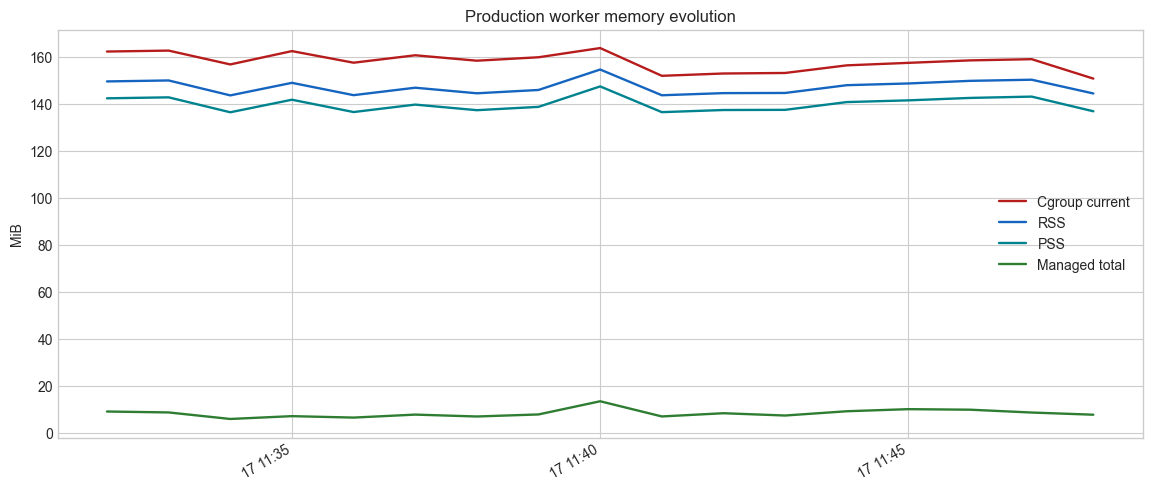

In [18]:
plot = df.set_index('timestamp')[['cgroupCurrentMiB', 'rssMiB', 'pssMiB', 'managedMiB']].resample('1min').median()
fig, ax = plt.subplots(figsize=(14, 6))
for column, color, label in [
    ('cgroupCurrentMiB', '#b71c1c', 'Cgroup current'),
    ('rssMiB', '#1565c0', 'RSS'),
    ('pssMiB', '#00838f', 'PSS'),
    ('managedMiB', '#2e7d32', 'Managed total'),
]:
    ax.plot(plot.index, plot[column], label=label, color=color, linewidth=1.7)
for segment_start in df.groupby('segment')['timestamp'].min().sort_values():
    ax.axvline(segment_start, color='#757575', alpha=0.25, linewidth=0.8)
ax.set_title('Production worker memory evolution across selected segments')
ax.set_ylabel('MiB')
ax.legend()
fig.autofmt_xdate()
plt.show()

## Cgroup category reconciliation

This view separates anonymous, file-backed, kernel-stack, and slab categories. The categories are cgroup accounting, not a claim that every byte belongs exclusively to the worker process.

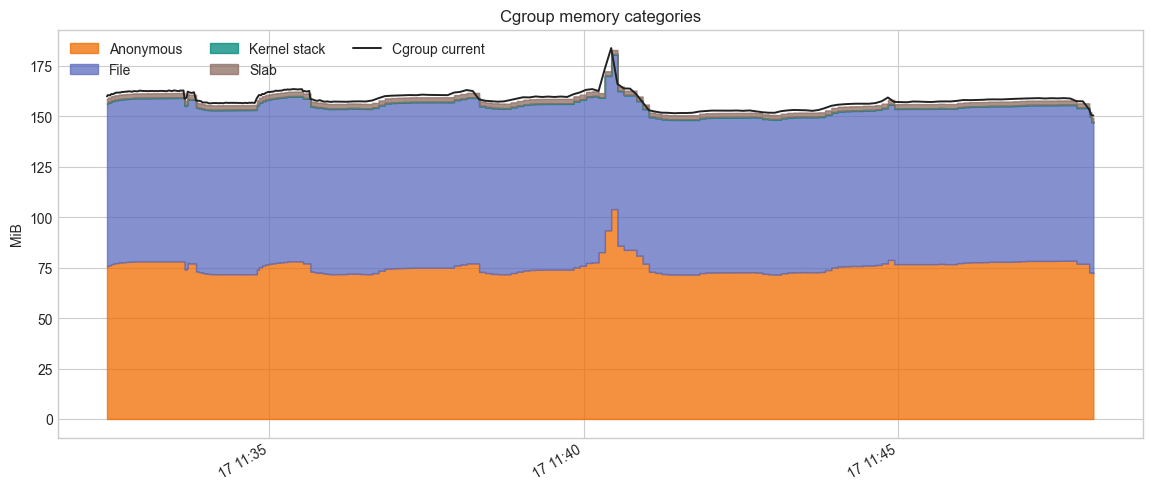

In [19]:
components = ['cgroupAnonymousMiB', 'cgroupFileMiB', 'cgroupKernelStackMiB', 'cgroupSlabMiB']
labels = ['Anonymous', 'File', 'Kernel stack', 'Slab']
colors = ['#ef6c00', '#5c6bc0', '#00897b', '#8d6e63']
fig, ax = plt.subplots(figsize=(14, 6))
base = np.zeros(len(df))
for column, label, color in zip(components, labels, colors):
    values = df[column.replace('Bytes', 'MiB')].fillna(0).to_numpy()
    ax.fill_between(df['timestamp'], base, base + values, step='post', alpha=0.75, label=label, color=color)
    base += values
ax.plot(df['timestamp'], df['cgroupCurrentMiB'], color='#212121', linewidth=1.4, label='Cgroup current')
ax.set_title('Cgroup memory categories')
ax.set_ylabel('MiB')
ax.legend(loc='upper left', ncol=3)
fig.autofmt_xdate()
plt.show()

## Operations, queue pressure, and event counters

These signals help distinguish memory growth caused by an active operation from growth that continues while the worker is otherwise idle.

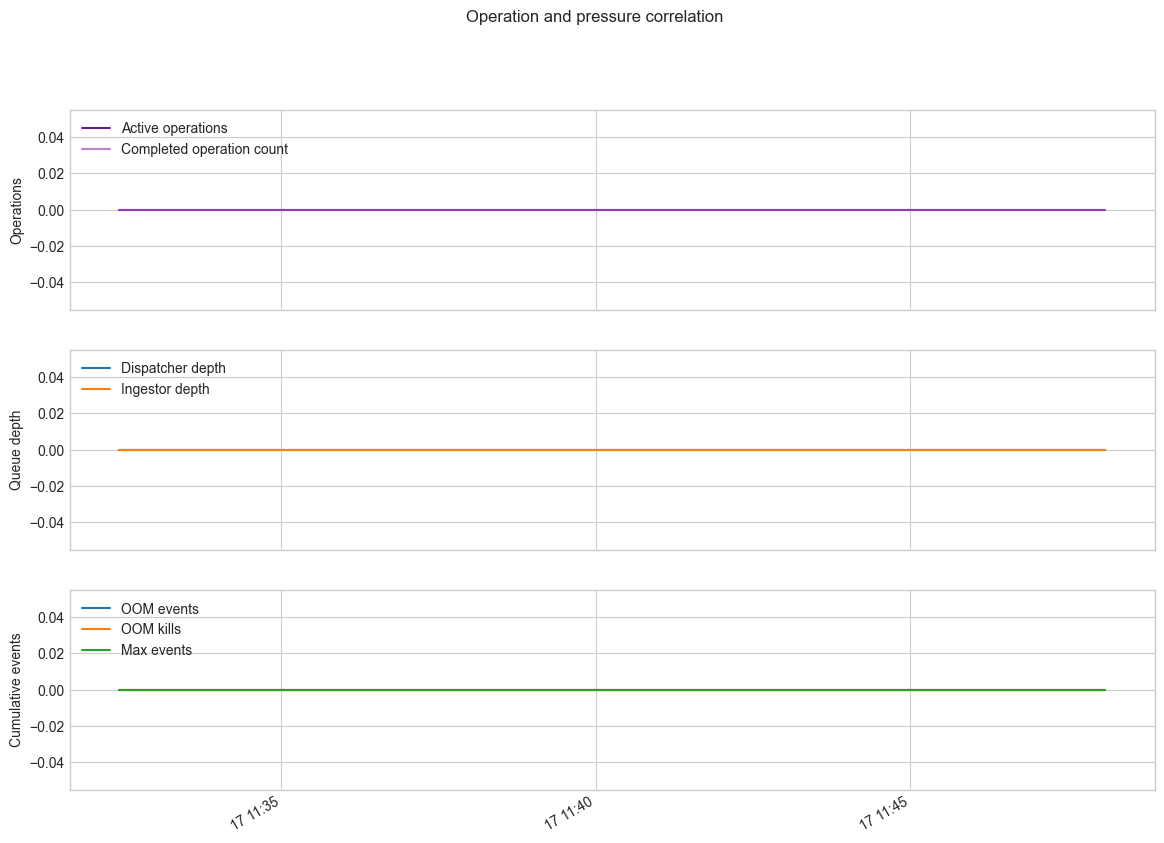

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(df['timestamp'], df['activeOperationCount'], color='#6a1b9a', label='Active operations')
axes[0].plot(df['timestamp'], df['operationCount'], color='#ab47bc', alpha=0.7, label='Completed operation count')
axes[0].legend(loc='upper left')
axes[0].set_ylabel('Operations')
axes[1].plot(df['timestamp'], df['dispatcherDepth'], label='Dispatcher depth')
axes[1].plot(df['timestamp'], df['ingestorDepth'], label='Ingestor depth')
axes[1].legend(loc='upper left')
axes[1].set_ylabel('Queue depth')
axes[2].step(df['timestamp'], df['memoryOomEvents'], where='post', label='OOM events')
axes[2].step(df['timestamp'], df['memoryOomKillEvents'], where='post', label='OOM kills')
axes[2].step(df['timestamp'], df['memoryMaxEvents'], where='post', label='Max events')
axes[2].legend(loc='upper left')
axes[2].set_ylabel('Cumulative events')
fig.suptitle('Operation and pressure correlation')
fig.autofmt_xdate()
plt.show()

In [21]:
def slope(frame, column):
    valid = frame[['elapsedMinutes', column]].dropna()
    if len(valid) < 2 or valid['elapsedMinutes'].nunique() < 2:
        return float('nan')
    return float(np.polyfit(valid['elapsedMinutes'], valid[column], 1)[0])

intervals = df['timestamp'].diff().dt.total_seconds().dropna()
summary_table = pd.DataFrame({
    'metric': ['Samples', 'Measured minutes', 'Peak cgroup current (MiB)', 'Peak RSS (MiB)', 'Peak PSS (MiB)', 'Peak managed (MiB)', 'RSS slope (MiB/min)', 'PSS slope (MiB/min)', 'Managed slope (MiB/min)', 'Median sample interval (s)', 'Intervals > 15s', 'Max OOM kills'],
    'value': [
        len(df), df['elapsedMinutes'].iloc[-1], df['cgroupCurrentMiB'].max(), df['rssMiB'].max(), df['pssMiB'].max(), df['managedMiB'].max(),
        slope(df, 'rssMiB'), slope(df, 'pssMiB'), slope(df, 'managedMiB'), intervals.median(), int((intervals > 15).sum()), df['memoryOomKillEvents'].max(),
    ],
})
display(summary_table)
print('Interpretation guardrails:')
print('- A slope is descriptive for this captured window; it is not proof of a leak.')
print('- The cgroup total includes file and kernel accounting, so compare it with the category plot.')
print('- Operation correlation is only possible where active-operation markers are present.')
print(f'- Selected segments: {len(candidates)}; unique parsed segments: {df["segment"].nunique()}')
print(f'- Duplicate records removed: {duplicate_records}')
print(f'- Malformed JSONL lines skipped: {len(malformed_lines)}')

,metric,value
0,Samples,264.000000
1,Measured minutes,15.683386
2,Peak cgroup current (MiB),183.910156
3,Peak RSS (MiB),174.769531
4,Peak PSS (MiB),167.586914
5,Peak managed (MiB),38.246262
6,RSS slope (MiB/min),0.052176
7,PSS slope (MiB/min),0.049387
8,Managed slope (MiB/min),0.119910
9,Median sample interval (s),2.000561


Interpretation guardrails:
- A slope is descriptive for this captured window; it is not proof of a leak.
- The cgroup total includes file and kernel accounting, so compare it with the category plot.
- Operation correlation is only possible where active-operation markers are present.
- Malformed JSONL lines skipped: 0


## Limitations

This notebook analyzes the selected production diagnostics segments only. GCS contains durable closed segments; the VM source is a point-in-time active-file copy and may grow after download. The combined timeline can span worker restarts, so compare segments and process IDs before interpreting slopes as a leak. It does not export credentials, command lines, environments, prompts, broker payloads, or raw market data.